## Breakdown of prevalence of A724E by study and geography

In this notebook, it might be interesting to also show how A724E prevalence varies by, for example, age?

```
df_prevdist.query("district == 'mushindamo'")
```

In [2]:
import os
import pandas as pd
import geopandas as gpd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

In [74]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
mpl.rcParams['font.family'] = 'Arial'
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [72]:
DIR_SEQDATA = "../seqdata/all/summaries/HRP23_MIS2024r1"
DIR_GEODATA = "../geodata/"
DIR_FIGS = "../figures/response/split-studies"
os.makedirs(DIR_FIGS, exist_ok=True)
save_results = True

In [5]:
W = 3.4 # roughly width of one column
KEEP_GEOCOLUMNS = ['province', 'district', 'area_sqkm', 'center_lat', 'center_lon', 'geometry']

In [6]:
prepare_metadata = False
if prepare_metadata:
    df = pd.read_csv("../metadata/2026-04-05_sample-duplication/table.zambia_all_data_combined.dedup.csv")
    df['study_province'] = [f"{study}-{province}" for study, province in zip(df["study"], df["province"])]
    df['study_district'] = [f"{study}-{district}" for study, district in zip(df["study"], df["district"])]
    df.to_csv("../metadata/2026-04-05_sample-duplication/table.zambia_all_data_combined.dedup.studyprov.csv")

## Functions

In [53]:
def annotate_for_manuscript(df: pd.DataFrame) -> pd.DataFrame:
    # Annotations
    # - Can improve
    df_geography = df.copy()
    df_geography['n_total'] = df_geography['n_mut'] + df_geography['n_mixed']
    df_geography["prevalence_table"] = [
        f"{r['prevalence']:.1f} ({r['prevalence_lowci']:.1f}-{r['prevalence_highci']:.1f})"
        for _, r in df_geography.iterrows()
    ]
    for c in ['n_total', 'n_mut', 'n_mixed']:
        df_geography[c] = df_geography[c].astype(int)
    
    return df_geography

In [24]:
def load_kelch13_a724e(csv: str) -> pd.DataFrame:
    """
    Load and annotate the A724E prevalence
    """
    df = pd.read_csv(csv).query("aa_change == 'A724E'")
    df = annotate_for_manuscript(df)

    return df

In [ ]:
mutation_column_names = {
    "prevalence_table": "Prevalence (95% CI) $-$ %",
    "n_passed": "N",
    "n_mut": "Mutant $-$ n",
    "n_mixed": "Mixed $-$ n",
    "n_total": "Mutant or Mixed $-$ n"
}

## Prepare prevalence estimates by study

#### Load geographical data

In [266]:
## Geodata
df_geo = gpd.read_file(
    f"{DIR_GEODATA}/zmb_admin_boundaries.shp",
    layer="zmb_admin1"
)
df_geo['province'] = [s.lower().replace("-", "") for s in df_geo['adm1_name']]
df_geo = df_geo[[c for c in KEEP_GEOCOLUMNS if c != 'district']]
order_province = df_geo.sort_values("center_lon")["province"].str.capitalize().tolist()
order_study = ['MIS2024', 'HRP23', 'Both'] # by size

#### Overall-study split

In [267]:
column_names = {
  #  "aa_change": "Mutation",
    'study': 'Study',
    "prevalence_table": "Prevalence (95% CI) $-$ %",
    "n_passed": "N",
    "n_mut": "Mutant $-$ n",
    "n_mixed": "Mixed $-$ n",
    "n_total": "Mutant or Mixed $-$ n"
}

In [281]:
# Overall
df_prev = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence.csv")
df_prev.insert(0, 'study', 'Both')

# By study
df_study = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence-study.csv")
df_clean_study = pd.concat([df_study, df_prev])[column_names.keys()].rename(column_names, axis=1)
df_clean_study['Study'] = pd.Categorical(df_clean_study['Study'],
                                         categories=order_study, ordered=True)
df_clean_study = df_clean_study.sort_values("Study")

In [282]:
df_clean_study

,Study,Prevalence (95% CI) $-$ %,N,Mutant $-$ n,Mixed $-$ n,Mutant or Mixed $-$ n
214,MIS2024,13.1 (9.4-17.6),283,13,24,37
463,HRP23,11.5 (10.0-13.2),1666,98,94,192
214,Both,11.7 (10.4-13.3),1949,111,118,229


#### Province study-split

In [283]:
columns_provinces = {
    'study': 'Study',
    'province': 'Province',
    "prevalence_table": "Prevalence (95% CI) $-$ %",
    "n_passed": "N",
    "n_mut": "Mutant $-$ n",
    "n_mixed": "Mixed $-$ n",
    "n_total": "Mutant or Mixed $-$ n"
}

In [284]:
df_prov = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence-province.csv")
df_prov.insert(0, 'study', 'Both')

In [285]:
df_study_prov = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence-study_province.csv")
df_study_prov['study'] = [s[0] for s in df_study_prov['study_province'].str.split("-")]
df_study_prov['province'] = [s[1] for s in df_study_prov['study_province'].str.split("-")]

In [286]:
df_clean_prov = pd.concat([df_study_prov, df_prov])[
    list(columns_provinces)].rename(columns_provinces, axis=1)

In [287]:
# Prepare for ordering
df_clean_prov['Study'] = pd.Categorical(df_clean_prov['Study'],
                                        categories=order_study, ordered=True)
df_clean_prov['Province'] = pd.Categorical(df_clean_prov['Province'].str.capitalize(), 
                                           categories=order_province, ordered=True)
df_clean_prov = df_clean_prov.sort_values(['Study', 'Province'])

In [288]:
df_clean_prov

,Study,Province,Prevalence (95% CI) $-$ %,N,Mutant $-$ n,Mixed $-$ n,Mutant or Mixed $-$ n
1234,MIS2024,Western,55.3 (38.3-71.4),38,7,14,21
724,MIS2024,Northwestern,28.9 (15.4-45.9),38,4,7,11
2491,MIS2024,Southern,0.0 (0.0-97.5),1,0,0,0
214,MIS2024,Copperbelt,10.8 (3.0-25.4),37,1,3,4
1489,MIS2024,Luapula,0.0 (0.0-11.9),29,0,0,0
4521,MIS2024,Lusaka,0.0 (0.0-36.9),8,0,0,0
1744,MIS2024,Central,0.0 (0.0-17.6),19,0,0,0
979,MIS2024,Northern,0.0 (0.0-7.4),48,0,0,0
4017,MIS2024,Muchinga,3.2 (0.1-16.7),31,1,0,1
4266,MIS2024,Eastern,0.0 (0.0-10.3),34,0,0,0


## Write tables

In [289]:
if save_results:
    df_clean_study.to_excel(f"{DIR_FIGS}/table.a724e_by_study.xlsx", index=False)
    df_clean_prov.to_excel(f"{DIR_FIGS}/table.a724e_by_province.xlsx", index=False)

## Fisher's exact

In [316]:
import scipy.stats as ss

In [323]:
df_study_fe = df_study[['study', 'n_wt', 'n_mut', 'n_mixed']]
df_study_fe['n_mutant'] = df_study_fe['n_mut'] + df_study_fe['n_mixed']
df_study_fe = df_study_fe.drop(['n_mut', 'n_mixed'], axis=1)
df_study_fe = df_study_fe.set_index('study')
df_study_fe.columns = ['wt', 'mutant']

/var/folders/w7/hc0fpn2s7ll378x1vzz2_pr00000gq/T/ipykernel_63557/362959393.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_study_fe['n_mutant'] = df_study_fe['n_mut'] + df_study_fe['n_mixed']


In [326]:
df_study_fe

,wt,mutant
study,,
MIS2024,246,37
HRP23,1474,192


In [325]:
ss.fisher_exact(df_study_fe)

SignificanceResult(statistic=np.float64(0.866038358575672), pvalue=np.float64(0.48430374763239603))

**Cross-table version**

In [182]:
KEEP_GEOCOLUMNS = ['province', 'district', 'area_sqkm', 'center_lat', 'center_lon', 'geometry']
KEEP_PREVCOLUMNS = ['study', 'province', 'n_passed', 'prevalence_table']

In [183]:
## Geodata
df_geo = gpd.read_file(
    f"{DIR_GEODATA}/zmb_admin_boundaries.shp",
    layer="zmb_admin1"
)
df_geo['province'] = [s.lower().replace("-", "") for s in df_geo['adm1_name']]
df_geo = df_geo[[c for c in KEEP_GEOCOLUMNS if c != 'district']]
order_province = df_geo.sort_values("center_lon")["province"].tolist()

## Load prevalence data
# Study dataframe
df_study = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence-study.csv")
df_study.insert(0, 'province', 'All')

# Province dataframe
df_prov = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence-study_province.csv")
df_prov['study'] = [s[0] for s in df_prov['study_province'].str.split("-")]
df_prov['province'] = [s[1] for s in df_prov['study_province'].str.split("-")]
df_prov = pd.concat([df_prov[KEEP_PREVCOLUMNS], df_study[KEEP_PREVCOLUMNS]])

In [184]:
# Pivot for paper
pt_prov = pd.pivot_table(
    index='province',
    columns='study',
    values=['n_passed', 'prevalence_table'],
    aggfunc=lambda x:x,
    data=df_prov
).loc[order_province + ['All']]
pt_prov.index = pt_prov.index.str.capitalize()
pt_prov = pt_prov.rename(index={"Northwestern": "North-Western"})
pt_prov['n_passed'] = pt_prov['n_passed'].fillna(0).astype(int)
pt_prov['prevalence_table'] = pt_prov['prevalence_table'].fillna("_")
pt_prov = pt_prov.rename(mutation_column_names, axis=1)

In [192]:
pt_prov

N         Prevalence (95% CI) $-$ %                  
study         HRP23 MIS2024                     HRP23           MIS2024
province                                                               
Western         179      38          51.4 (43.8-58.9)  55.3 (38.3-71.4)
North-Western   146      38          56.8 (48.4-65.0)  28.9 (15.4-45.9)
Southern          0       1                         _    0.0 (0.0-97.5)
Copperbelt      238      37             2.1 (0.7-4.8)   10.8 (3.0-25.4)
Luapula         377      29             0.0 (0.0-1.0)    0.0 (0.0-11.9)
Lusaka           82       8            9.8 (4.3-18.3)    0.0 (0.0-36.9)
Central         110      19             3.6 (1.0-9.0)    0.0 (0.0-17.6)
Northern         49      48             0.0 (0.0-7.3)     0.0 (0.0-7.4)
Muchinga        138      31             0.0 (0.0-2.6)    3.2 (0.1-16.7)
Eastern         347      34             0.0 (0.0-1.1)    0.0 (0.0-10.3)
All            1666     283          11.5 (10.0-13.2)   13.1 (9.4-17.6)

In [191]:
if save_results:
    pt_prov.to_csv(f"{DIR_FIGS}/table.a724_by_study_province.csv")
    pt_prov.to_excel(f"{DIR_FIGS}/table.a724_by_study_province.xlsx")

## District analysis

In [290]:
## Load geographical district data
df_geo = gpd.read_file(
    f"{DIR_GEODATA}/zmb_admin_boundaries.shp",
    layer="zmb_admin2"
)
df_geo['district'] = df_geo['adm2_name'].str.lower()
df_geo['province'] = df_geo['adm1_name'].str.lower()
df_geo = df_geo[KEEP_GEOCOLUMNS]

# District dataframe
df_dist = load_kelch13_a724e(f"{DIR_SEQDATA}/summary.variants.prevalence-study_district.csv")
df_dist['study'] = [s[0] for s in df_dist['study_district'].str.split("-")]
df_dist['district'] = [s[1] for s in df_dist['study_district'].str.split("-")]
df_dist = df_geo.merge(right=df_dist, how='left', on='district', validate='1:m')

In [291]:
pt_dist = pd.pivot_table(
    index='district',
    columns='study',
    values=['n_passed', 'n_total', 'prevalence', 'prevalence_lowci', 'prevalence_highci', 'prevalence_table'],
    aggfunc=lambda x:x,
    data=df_dist
)

In [292]:
pt_dist.head()

n_passed         n_total         prevalence          \
study       HRP23 MIS2024   HRP23 MIS2024      HRP23 MIS2024   
district                                                       
chama         NaN     1.0     NaN     0.0        NaN     0.0   
chasefu       NaN    10.0     NaN     0.0        NaN     0.0   
chavuma      16.0     1.0     6.0     1.0  37.500000   100.0   
chembe       21.0     3.0     0.0     0.0   0.000000     0.0   
chibombo     34.0     NaN     4.0     NaN  11.764706     NaN   

         prevalence_highci             prevalence_lowci          \
study                HRP23     MIS2024            HRP23 MIS2024   
district                                                          
chama                  NaN   97.500000              NaN     0.0   
chasefu                NaN   30.849711              NaN     0.0   
chavuma          64.565391  100.000000        15.198368     2.5   
chembe           16.109762   70.759823         0.000000     0.0   
chibombo         27.450349         NaN         3.300168     NaN   

          prevalence_table                     
study                HRP23            MIS2024  
district                                       
chama                  NaN     0.0 (0.0-97.5)  
chasefu                NaN     0.0 (0.0-30.8)  
chavuma   37.5 (15.2-64.6)  100.0 (2.5-100.0)  
chembe      0.0 (0.0-16.1)     0.0 (0.0-70.8)  
chibombo   11.8 (3.3-27.5)                NaN

In [293]:
common_dists = pt_dist['n_passed'].query("HRP23 >= 5 and MIS2024 >= 5").index
pt_dist.loc[common_dists][['n_passed', 'prevalence_table']]

n_passed          prevalence_table                  
study            HRP23 MIS2024             HRP23           MIS2024
district                                                          
chipangali        89.0     5.0     0.0 (0.0-4.1)    0.0 (0.0-52.2)
kalumbila         17.0     9.0  52.9 (27.8-77.0)  44.4 (13.7-78.8)
kanchibiya        11.0     7.0    0.0 (0.0-28.5)    0.0 (0.0-41.0)
kaoma             24.0     5.0  54.2 (32.8-74.4)  80.0 (28.4-99.5)
kapiri mposhi     11.0     8.0    0.0 (0.0-28.5)    0.0 (0.0-36.9)
lufwanyama        28.0    15.0   10.7 (2.3-28.2)   26.7 (7.8-55.1)
masaiti           18.0     5.0    0.0 (0.0-18.5)    0.0 (0.0-52.2)
milenge           51.0     6.0     0.0 (0.0-7.0)    0.0 (0.0-45.9)
mpongwe           21.0     7.0    0.0 (0.0-16.1)    0.0 (0.0-41.0)
mushindamo        10.0    19.0   10.0 (0.3-44.5)    5.3 (0.1-26.0)
rufunsa           32.0     7.0    0.0 (0.0-10.9)    0.0 (0.0-41.0)
senga hill         6.0     8.0    0.0 (0.0-45.9)    0.0 (0.0-36.9)
sikongo           26.0     7.0  65.4 (44.3-82.8)   28.6 (3.7-71.0)

- Looking at just districts with at least 5 samples in each study

In [299]:
df_dist.province.unique()

array(['central', 'copperbelt', 'eastern', 'luapula', 'lusaka',
       'muchinga', 'northern', 'north-western', 'southern', 'western'],
      dtype=object)

In [307]:
df_nw = (df_dist.query("province == 'north-western'")
    .sort_values(["study", "n_passed"], ascending=False))[
    ['study', 'province', 'district', 'n_passed', 'n_mut', 'n_mixed', 'n_wt', 'prevalence_table']
]
df_nw

,study,province,district,n_passed,n_mut,n_mixed,n_wt,prevalence_table
112,MIS2024,north-western,mushindamo,19.0,0.0,1.0,18.0,5.3 (0.1-26.0)
110,MIS2024,north-western,kalumbila,9.0,0.0,4.0,5.0,44.4 (13.7-78.8)
106,MIS2024,north-western,mwinilunga,5.0,0.0,1.0,4.0,20.0 (0.5-71.6)
103,MIS2024,north-western,manyinga,2.0,2.0,0.0,0.0,100.0 (15.8-100.0)
97,MIS2024,north-western,chavuma,1.0,1.0,0.0,0.0,100.0 (2.5-100.0)
105,MIS2024,north-western,mufumbwe,1.0,0.0,1.0,0.0,100.0 (2.5-100.0)
109,MIS2024,north-western,zambezi,1.0,1.0,0.0,0.0,100.0 (2.5-100.0)
104,HRP23,north-western,mufumbwe,27.0,8.0,9.0,10.0,63.0 (42.4-80.6)
102,HRP23,north-western,manyinga,20.0,8.0,7.0,5.0,75.0 (50.9-91.3)
100,HRP23,north-western,kabompo,17.0,10.0,4.0,3.0,82.4 (56.6-96.2)


In [308]:
df_new.query("study == 'MIS2024'").n_passed.sum()

np.float64(38.0)

In [311]:
19/38

0.5

In [312]:
120/136

0.8823529411764706

## Plot map

In [64]:
LW = 0.5
MIN_LON, MAX_LON = 21, 34

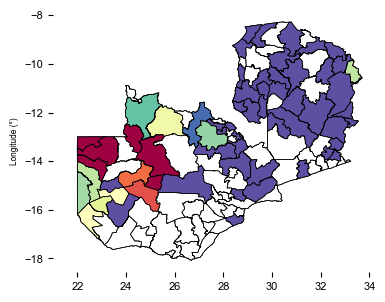

In [81]:
# Define study to plot
plot_study = 'MIS2024'
min_samples = 0
df_plot = df_dist.query("study == @plot_study and n_passed > @min_samples")
df_plot.shape[0]

# Plot
SCALE = 0.6
fig, ax = plt.subplots(1, 1, figsize=(W*2*SCALE, 8*SCALE))

# Plot prevalence of A724E
df_plot.plot(
    column='prevalence',
    cmap='Spectral_r',
    vmin=0, vmax=100,
    # Unfortunately, adding the cbar distorts the plot size; handle separately
    # legend=True,
    # legend_kwds=dict(label="Prevalence (%)", 
    #                  shrink=0.3,
    #                  aspect=10),
    ax=ax
)

# Plot district outlines
df_geo.boundary.plot(
    lw=LW, color='black',
    ax=ax
)

# Strengthen outer border
gpd.GeoSeries([df_geo.union_all()]).boundary.plot(ax=ax,
                                                  lw=LW, 
                                                  color='black')

# Limits
ax.set_xlim(MIN_LON, MAX_LON)

# Labels
ax.set_ylabel("Latitude (°)", fontsize=6)
ax.set_ylabel("Longitude (°)", fontsize=6)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.zambia_prevalence.{plot_study}.n{min_samples}.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.zambia_prevalence.{plot_study}.n{min_samples}.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

## Plot comparisons

(0.0, 100.0)

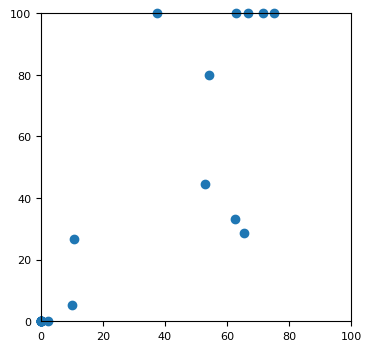

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(
    x=pt_dist['prevalence']['HRP23'],
    y=pt_dist['prevalence']['MIS2024'],
    clip_on=False,
)
ax.set_axisbelow(True)

ax.set_xlim((0, 100))
ax.set_ylim((0, 100))